<a href="https://colab.research.google.com/github/AngeloSorte/Loan-Approval-Prediction/blob/angelosorte.github.io/Loan_Approval_Prediction_%E2%80%94_Banking_Risk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (1000, 6)

Accuracy: 0.98

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       179
           1       0.97      0.96      0.96        71

    accuracy                           0.98       250
   macro avg       0.98      0.97      0.98       250
weighted avg       0.98      0.98      0.98       250



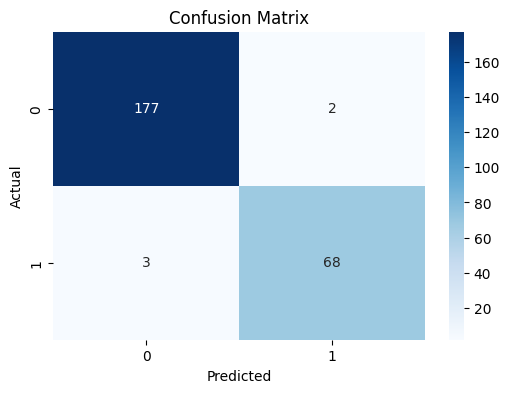

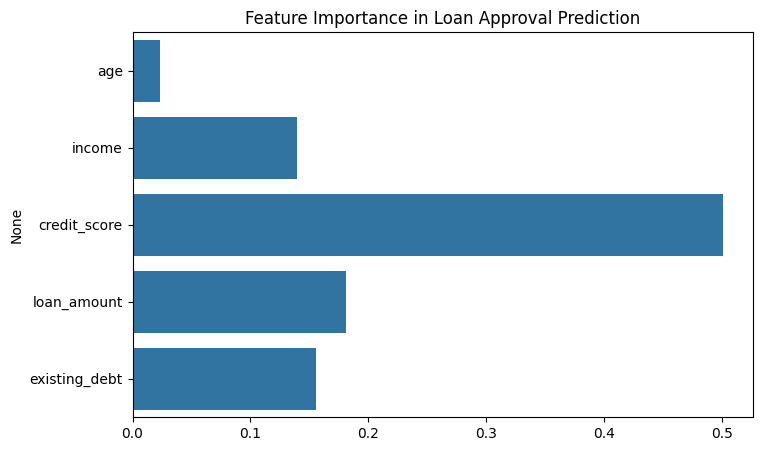

In [1]:
# Loan Approval Prediction — Banking Risk Model
# This Colab implements a full ML pipeline to predict loan approval
# using simulated customer data, including preprocessing, model training,
# evaluation, and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --------------------------------------------
# Step 1: Simulated loan dataset
# --------------------------------------------
np.random.seed(42)

# Simulate features
n = 1000
data = {
    "age": np.random.randint(20, 70, n),
    "income": np.random.randint(20000, 120000, n),
    "credit_score": np.random.randint(300, 850, n),
    "loan_amount": np.random.randint(5000, 50000, n),
    "existing_debt": np.random.randint(0, 20000, n)
}

df = pd.DataFrame(data)

# Simulate approval decision
df["approved"] = (
    (df["credit_score"] > 600) &
    (df["income"] > 35000) &
    (df["existing_debt"] < df["loan_amount"] / 2)
).astype(int)

print("Dataset shape:", df.shape)
df.head()

# --------------------------------------------
# Step 2: Train-test split
# --------------------------------------------
X = df.drop("approved", axis=1)
y = df["approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# --------------------------------------------
# Step 3: Feature scaling
# --------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------
# Step 4: Model training
# --------------------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# --------------------------------------------
# Step 5: Evaluation
# --------------------------------------------
y_pred = model.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance
importances = model.feature_importances_
feat_names = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance in Loan Approval Prediction")
plt.show()